In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
#===========================================
# Load File 1
#===========================================

with open('Phi_Gaussian_Exp_MMD.npy', 'rb') as f:
    sample_losses_01_exp = jnp.load(f)
    
with open('Phi_Gaussian_Relu_MMD.npy', 'rb') as f:
    sample_losses_01_relu = jnp.load(f)

with open('Phi_Gaussian_Square_MMD.npy', 'rb') as f:
    sample_losses_01_square = jnp.load(f)

with open('Phi_Bimodal_Exp_MMD.npy', 'rb') as f:
    sample_losses_02_exp = jnp.load(f)
    
with open('Phi_Bimodal_Relu_MMD.npy', 'rb') as f:
    sample_losses_02_relu = jnp.load(f)

with open('Phi_Bimodal_Square_MMD.npy', 'rb') as f:
    sample_losses_02_square = jnp.load(f)

with open('Phi_Banana_Exp_MMD.npy', 'rb') as f:
    sample_losses_03_exp = jnp.load(f)
    
with open('Phi_Banana_Relu_MMD.npy', 'rb') as f:
    sample_losses_03_relu = jnp.load(f)

with open('Phi_Banana_Square_MMD.npy', 'rb') as f:
    sample_losses_03_square = jnp.load(f)
    
sample_losses_01_list = [ sample_losses_01_exp, sample_losses_01_relu, sample_losses_01_square ]
sample_losses_02_list = [ sample_losses_02_exp, sample_losses_02_relu, sample_losses_02_square ]
sample_losses_03_list = [ sample_losses_03_exp, sample_losses_03_relu, sample_losses_03_square ]


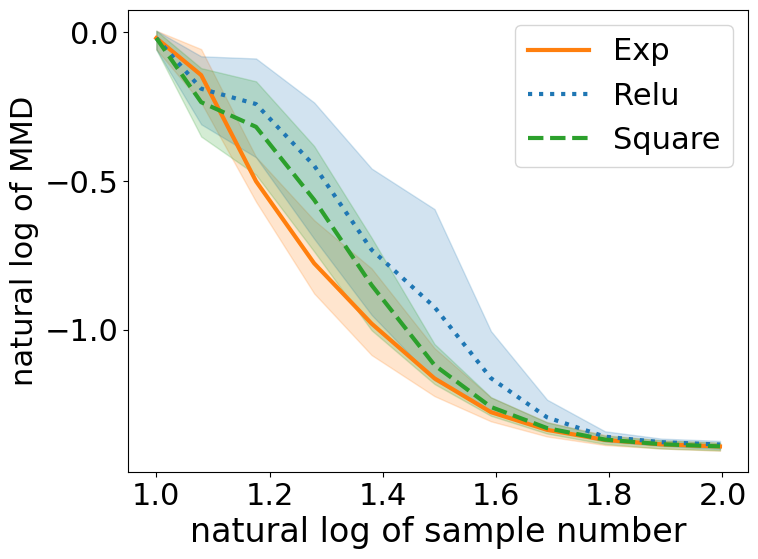

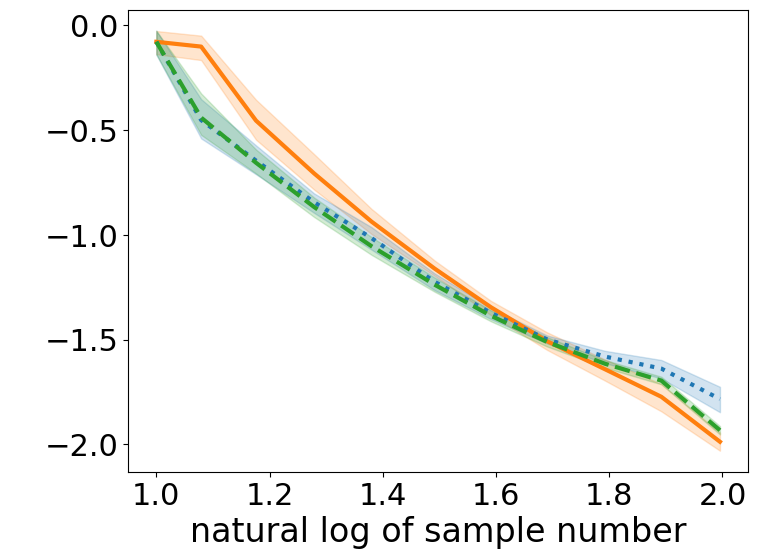

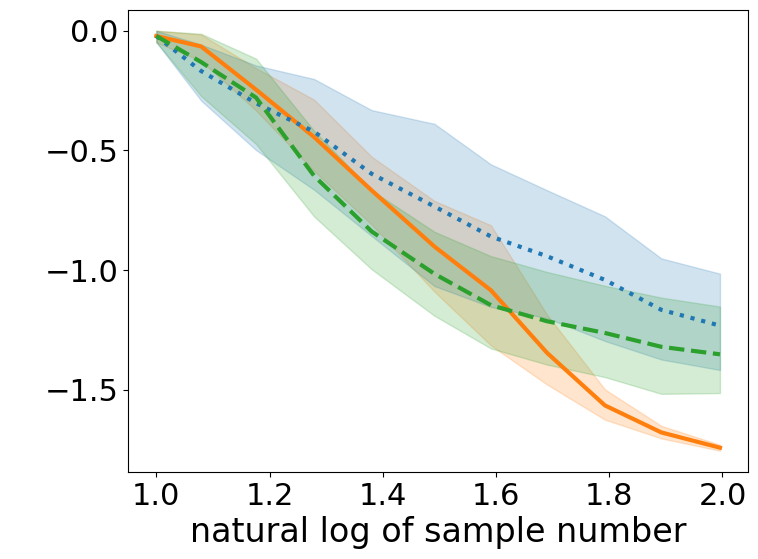

In [3]:
#===========================================
# Visualise Sample Losses
#===========================================

def plot_sample_loss(loss_list, init_num=10, total_num=100, ytick=None, xlabel=True, ylabel=True, legend=True):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    loss_index = jnp.log10( jnp.array([10, 12, 15, 19, 24, 31, 39, 49, 62, 78, 99]) )
    df_exp = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[0].flatten())})
    df_relu = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[1].flatten())})
    df_square = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[2].flatten())})

    sns.lineplot(df_exp, x='index', y='loss', ax=ax, linestyle='solid', linewidth=3, color=sns.color_palette()[1], label="Exp")
    sns.lineplot(df_relu, x='index', y='loss', ax=ax, linestyle='dotted', linewidth=3, color=sns.color_palette()[0], label="Relu")
    sns.lineplot(df_square, x='index', y='loss', ax=ax, linestyle='dashed', linewidth=3, color=sns.color_palette()[2], label="Square")

    if ytick:
        ax.set_yticks(ytick)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.set_xlabel("natural log of sample number", fontsize=24) if xlabel else ax.set_xlabel(" ", fontsize=22)
    ax.set_ylabel("natural log of MMD", fontsize=22) if ylabel else ax.set_ylabel(" ", fontsize=22)
    ax.legend(prop=dict(size=22)) if legend else ax.get_legend().remove()

plot_sample_loss(sample_losses_01_list, ytick=[0.0, -0.5, -1.0])
plot_sample_loss(sample_losses_02_list, ylabel=False, legend=False)
plot_sample_loss(sample_losses_03_list, ylabel=False, legend=False)
